<a href="https://colab.research.google.com/github/gerenciaracemachine-cpu/regresiones-lineales/blob/main/Perceptron.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import numpy as np

class PerceptronSimple:
    def __init__(self, num_entradas, tasa_aprendizaje=0.1):
        # 1. Inicializamos los pesos en valores aleatorios pequeños y el bias en 0
        self.pesos = np.random.uniform(-0.5, 0.5, num_entradas)
        self.bias = 0.0
        self.lr = tasa_aprendizaje

    def funcion_escalon(self, z):
        # Retorna 1 si z >= 0, de lo contrario 0
        return 1 if z >= 0 else 0

    def predecir(self, x):
        # Calculamos la suma ponderada z = W * X + b
        z = np.dot(x, self.pesos) + self.bias
        # Aplicamos la función de activación
        return self.funcion_escalon(z)

In [9]:
# Instanciamos un perceptrón con 2 entradas (por ejemplo x1, x2)
perceptron = PerceptronSimple(num_entradas=2, tasa_aprendizaje=0.1)

print("Pesos iniciales (aleatorios):", perceptron.pesos)
print("Bias inicial:", perceptron.bias)

# Probamos una predicción con la entrada [1, 1]
entrada_prueba = np.array([1, 1])
prediccion_inicial = perceptron.predecir(entrada_prueba)

print(f"Predicción para la entrada {entrada_prueba}: {prediccion_inicial}")

Pesos iniciales (aleatorios): [-0.04700547  0.37324808]
Bias inicial: 0.0
Predicción para la entrada [1 1]: 1


In [11]:
import numpy as np

class PerceptronSimple:
    def __init__(self, num_entradas, tasa_aprendizaje=0.1, epocas=100):
        self.pesos = np.random.uniform(-0.5, 0.5, num_entradas)
        self.bias = 0.0
        self.lr = tasa_aprendizaje
        self.epocas = epocas  # Número de pasadas completas por los datos

    def funcion_escalon(self, z):
        return 1 if z >= 0 else 0

    def predecir(self, x):
        z = np.dot(x, self.pesos) + self.bias
        return self.funcion_escalon(z)

    def fit(self, X, y):
        """
        Entrena el perceptrón ajustando los pesos y el bias.
        X: matriz de entradas (ej: de forma (4, 2))
        y: vector de salidas esperadas
        """
        for epoca in range(self.epocas):
            errores_totales = 0

            for entradas, objetivo in zip(X, y):
                # 1. Realizar predicción
                prediccion = self.predecir(entradas)

                # 2. Calcular el error
                error = objetivo - prediccion

                # 3. Actualizar pesos y bias si hubo un error
                if error != 0:
                    self.pesos += self.lr * error * entradas
                    self.bias += self.lr * error
                    errores_totales += abs(error)

            # Si en toda la época el error total fue 0, el modelo ya aprendió
            if errores_totales == 0:
                print(f" Convergencia alcanzada en la época {epoca + 1}")
                break

In [3]:
import numpy as np

class PerceptronSimple:
    def __init__(self, num_entradas, tasa_aprendizaje=0.1, epocas=100):
        self.pesos = np.random.uniform(-0.5, 0.5, num_entradas)
        self.bias = 0.0
        self.lr = tasa_aprendizaje
        self.epocas = epocas

    def funcion_escalon(self, z):
        return 1 if z >= 0 else 0

    def predecir(self, x):
        z = np.dot(x, self.pesos) + self.bias
        return self.funcion_escalon(z)

    def fit(self, X, y):
        for epoca in range(self.epocas):
            errores_totales = 0

            for entradas, objetivo in zip(X, y):
                prediccion = self.predecir(entradas)
                error = objetivo - prediccion

                if error != 0:
                    self.pesos += self.lr * error * entradas
                    self.bias += self.lr * error
                    errores_totales += abs(error)

            if errores_totales == 0:
                print(f" Convergencia alcanzada en la época {epoca + 1}")
                break

# 1. Datos de entrenamiento (Compuerta AND)
X_and = np.array(
    [
        [0, 0],
        [0, 1],
        [1, 0],
        [1, 1]
    ]
)

y_and = np.array([0, 0, 0, 1])

# 2. Creación e inicialización del modelo
perceptron = PerceptronSimple(num_entradas=2, tasa_aprendizaje=0.1, epocas=100)

print("--- PESOS INICIALES ---")
print("Pesos:", perceptron.pesos)
print("Bias:", perceptron.bias)

# 3. Entrenamiento
perceptron.fit(X_and, y_and)

print("\n--- RESULTADOS TRAS EL ENTRENAMIENTO ---")
print("Pesos finales:", perceptron.pesos)
print("Bias final:", perceptron.bias)

# 4. Evaluación de predicciones
print("\n--- EVALUACIÓN DE PREDICCIONES ---")
for x in X_and:
    print(f"Entrada: {x} -> Predicción: {perceptron.predecir(x)}")

--- PESOS INICIALES ---
Pesos: [ 0.3456312  -0.43545782]
Bias: 0.0
 Convergencia alcanzada en la época 9

--- RESULTADOS TRAS EL ENTRENAMIENTO ---
Pesos finales: [0.1456312  0.16454218]
Bias final: -0.30000000000000004

--- EVALUACIÓN DE PREDICCIONES ---
Entrada: [0 0] -> Predicción: 0
Entrada: [0 1] -> Predicción: 0
Entrada: [1 0] -> Predicción: 0
Entrada: [1 1] -> Predicción: 1


Convergencia alcanzada en la época 5


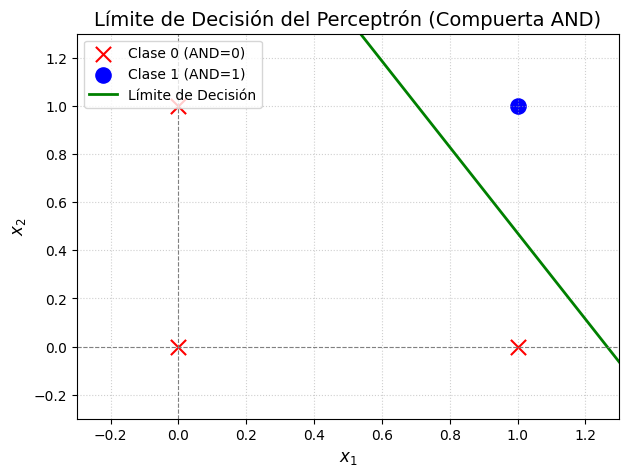

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Definición de la clase Perceptrón Simple
class PerceptronSimple:
    def __init__(self, num_entradas, tasa_aprendizaje=0.1, epocas=100):
        self.pesos = np.random.uniform(-0.5, 0.5, num_entradas)
        self.bias = 0.0
        self.lr = tasa_aprendizaje
        self.epocas = epocas

    def funcion_escalon(self, z):
        return 1 if z >= 0 else 0

    def predecir(self, x):
        z = np.dot(x, self.pesos) + self.bias
        return self.funcion_escalon(z)

    def fit(self, X, y):
        for epoca in range(self.epocas):
            errores_totales = 0
            for entradas, objetivo in zip(X, y):
                prediccion = self.predecir(entradas)
                error = objetivo - prediccion
                if error != 0:
                    self.pesos += self.lr * error * entradas
                    self.bias += self.lr * error
                    errores_totales += abs(error)
            if errores_totales == 0:
                print(f"Convergencia alcanzada en la época {epoca + 1}")
                break

# 2. Datos de la Compuerta Lógica AND
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])
y = np.array([0, 0, 0, 1])

# 3. Entrenamiento del Modelo
perceptron = PerceptronSimple(num_entradas=2, tasa_aprendizaje=0.1, epocas=100)
perceptron.fit(X, y)

# 4. Función para Graficar los Puntos y la Recta de Decisión
def graficar_limite_decision(X, y, modelo):
    plt.figure(figsize=(7, 5))

    # Graficar los puntos de datos (0 = Rojo, 1 = Azul)
    for i in range(len(y)):
        if y[i] == 1:
            plt.scatter(X[i, 0], X[i, 1], color='blue', marker='o', s=120, label='Clase 1 (AND=1)' if i == 3 else "")
        else:
            plt.scatter(X[i, 0], X[i, 1], color='red', marker='x', s=120, label='Clase 0 (AND=0)' if i == 0 else "")

    # Calcular la recta del límite de decisión: w1*x1 + w2*x2 + b = 0  =>  x2 = -(w1*x1 + b) / w2
    w1, w2 = modelo.pesos
    b = modelo.bias

    x1_linea = np.linspace(-0.5, 1.5, 100)

    # Prevenir división por cero si w2 resulta ser 0
    if w2 != 0:
        x2_linea = -(w1 * x1_linea + b) / w2
        plt.plot(x1_linea, x2_linea, color='green', linewidth=2, label='Límite de Decisión')

    # Configuración de los ejes y estética del gráfico
    plt.xlim(-0.3, 1.3)
    plt.ylim(-0.3, 1.3)
    plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
    plt.xlabel('$x_1$', fontsize=12)
    plt.ylabel('$x_2$', fontsize=12)
    plt.title('Límite de Decisión del Perceptrón (Compuerta AND)', fontsize=14)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='upper left')
    plt.show()

# Mostrar el gráfico
graficar_limite_decision(X, y, perceptron)

In [ ]:
# AHORA VAMOS A HACER UN PERCEPTRON MULTICAPA

In [5]:
import numpy as np
import matplotlib.pyplot as plt

class PerceptronMulticapa:
    def __init__(self, num_entradas=2, num_ocultas=3, num_salidas=1, tasa_aprendizaje=0.5, epocas=10000):
        self.lr = tasa_aprendizaje
        self.epocas = epocas

        # 1. Pesos y bias para la Capa Oculta (Capa 1)
        self.W1 = np.random.uniform(-1, 1, (num_entradas, num_ocultas))
        self.b1 = np.zeros((1, num_ocultas))

        # 2. Pesos y bias para la Capa de Salida (Capa 2)
        self.W2 = np.random.uniform(-1, 1, (num_ocultas, num_salidas))
        self.b2 = np.zeros((1, num_salidas))

    def sigmoide(self, z):
        return 1.0 / (1.0 + np.exp(-z))

    def derivada_sigmoide(self, a):
        # Derivada en términos de la salida activada 'a'
        return a * (1.0 - a)

    def forward(self, X):
        """Paso hacia adelante (Forward Pass)"""
        # Capa Oculta
        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = self.sigmoide(self.z1)

        # Capa de Salida
        self.z2 = np.dot(self.a1, self.W2) + self.b2
        self.a2 = self.sigmoide(self.z2)

        return self.a2

    def fit(self, X, y):
        """Entrenamiento con Backpropagation"""
        y = y.reshape(-1, 1) # Asegurar dimensión de columna (4, 1)

        for epoca in range(self.epocas):
            # --- 1. FORWARD PASS ---
            salida = self.forward(X)

            # --- 2. CÁLCULO DEL ERROR ---
            error_salida = y - salida

            # --- 3. BACKPROPAGATION ---
            # Gradiente en la capa de salida (Delta 2)
            delta2 = error_salida * self.derivada_sigmoide(salida)

            # Propagación del error a la capa oculta
            error_oculto = np.dot(delta2, self.W2.T)
            # Gradiente en la capa oculta (Delta 1)
            delta1 = error_oculto * self.derivada_sigmoide(self.a1)

            # --- 4. ACTUALIZACIÓN DE PESOS Y BIAS ---
            self.W2 += np.dot(self.a1.T, delta2) * self.lr
            self.b2 += np.sum(delta2, axis=0, keepdims=True) * self.lr

            self.W1 += np.dot(X.T, delta1) * self.lr
            self.b1 += np.sum(delta1, axis=0, keepdims=True) * self.lr

    def predecir(self, X):
        salida = self.forward(X)
        # Convertimos la probabilidad continua a clase binaria 0 o 1
        return (salida >= 0.5).astype(int)

# --- PRUEBA CON LA COMPUERTA NO LINEAL: XOR ---
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y_xor = np.array([0, 1, 1, 0])

# Instanciar y entrenar el MLP
mlp = PerceptronMulticapa(num_entradas=2, num_ocultas=3, num_salidas=1, tasa_aprendizaje=0.5, epocas=10000)
mlp.fit(X, y_xor)

# Evaluación de resultados
print("--- RESULTADOS EN COMPUERTA XOR (MLP) ---")
for i in range(len(X)):
    probabilidad = mlp.forward(X[i:i+1])[0][0]
    prediccion = mlp.predecir(X[i:i+1])[0][0]
    print(f"Entrada: {X[i]} -> Probabilidad: {probabilidad:.4f} -> Clase: {prediccion} (Esperado: {y_xor[i]})")

--- RESULTADOS EN COMPUERTA XOR (MLP) ---
Entrada: [0 0] -> Probabilidad: 0.0163 -> Clase: 0 (Esperado: 0)
Entrada: [0 1] -> Probabilidad: 0.9863 -> Clase: 1 (Esperado: 1)
Entrada: [1 0] -> Probabilidad: 0.9841 -> Clase: 1 (Esperado: 1)
Entrada: [1 1] -> Probabilidad: 0.0140 -> Clase: 0 (Esperado: 0)


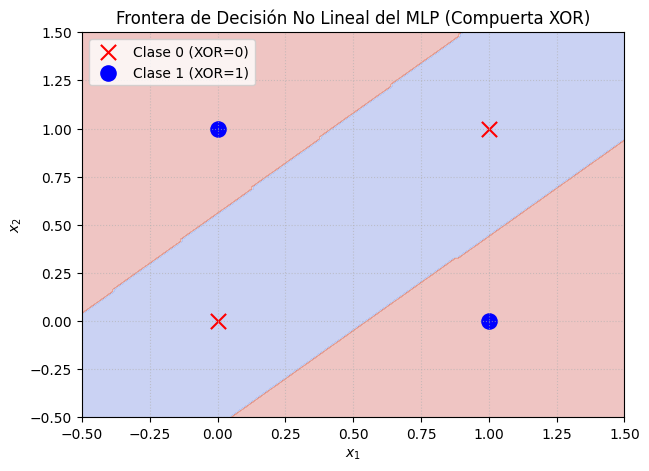

In [6]:
def graficar_frontera_mlp(X, y, modelo):
    plt.figure(figsize=(7, 5))

    # Crear una malla fina de puntos para evaluar el espacio de decisiones
    x_min, x_max = -0.5, 1.5
    y_min, y_max = -0.5, 1.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))

    # Evaluar la predicción del MLP en cada punto de la malla
    malla_puntos = np.c_[xx.ravel(), yy.ravel()]
    Z = modelo.predecir(malla_puntos)
    Z = Z.reshape(xx.shape)

    # Dibujar la frontera de decisión con colores
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)

    # Dibujar los puntos reales
    for i in range(len(y)):
        if y[i] == 1:
            plt.scatter(X[i, 0], X[i, 1], color='blue', marker='o', s=120, label='Clase 1 (XOR=1)' if i == 1 else "")
        else:
            plt.scatter(X[i, 0], X[i, 1], color='red', marker='x', s=120, label='Clase 0 (XOR=0)' if i == 0 else "")

    plt.title('Frontera de Decisión No Lineal del MLP (Compuerta XOR)')
    plt.xlabel('$x_1$')
    plt.ylabel('$x_2$')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='upper left')
    plt.show()

graficar_frontera_mlp(X, y_xor, mlp)

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# 1. Cargar el Dataset MNIST (Dígitos del 0 al 9)
mnist = tf.keras.datasets.mnist
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalización de los píxeles a rango [0, 1]
X_train, X_test = X_train / 255.0, X_test / 255.0

# 2. Construcción del Perceptrón Multicapa (MLP) con activación ReLU y Softmax
# Nota: No se usan capas convolucionales, solo capas Densas (Fully Connected)
model = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),          # Aplanar imágenes de 28x28 a vector de 784
    layers.Dense(128, activation='relu'),           # Capa oculta 1 con ReLU
    layers.Dense(64, activation='relu'),            # Capa oculta 2 con ReLU
    layers.Dense(10, activation='softmax')          # Capa de salida para 10 clases (0-9)
])

# 3. Compilación del modelo
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 4. Entrenamiento del modelo
history = model.fit(X_train, y_train, epochs=5, validation_data=(X_test, y_test))

# 5. Evaluación en datos de prueba
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)
print(f"\n Precisión final en el conjunto de prueba (MNIST): {test_acc * 100:.2f}%")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9301 - loss: 0.2413 - val_accuracy: 0.9625 - val_loss: 0.1266
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9692 - loss: 0.1016 - val_accuracy: 0.9649 - val_loss: 0.1073
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 4ms/step - accuracy: 0.9777 - loss: 0.0722 - val_accuracy: 0.9639 - val_loss: 0.1126
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9821 - loss: 0.0559 - val_accuracy: 0.9762 - val_loss: 0.0785
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9858 - loss: 0.0432 - val_accuracy: 0.9739 - val_loss: 0.0860
313/313 - 1s - 2ms/step - accuracy: 0.9739 - loss: 0.0860

 Precisión final en el conjunto de prueba (MNIST): 97.39%
